# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

In [5]:
df_diabetes = pd.read_csv("diabetes_dataset.csv")
df_kidney = pd.read_csv("Kidney_dataset.csv")
df_hypertension = pd.read_csv("hypertension_dataset.csv")

print("Diabetes Dataset:")
print(df_diabetes.head(), "\n")

print("Kidney Dataset:")
print(df_kidney.head(), "\n")

print("Hypertension Dataset:")
print(df_hypertension.head(), "\n")

Diabetes Dataset:
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       0.0        1.0  26.0     0.0     0.0   
1              0.0     1.0       1.0        1.0  26.0     1.0     1.0   
2              0.0     0.0       0.0        1.0  26.0     0.0     0.0   
3              0.0     1.0       1.0        1.0  28.0     1.0     0.0   
4              0.0     0.0       0.0        1.0  29.0     1.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           1.0     0.0  ...            1.0   
1                   0.0           0.0     1.0  ...            1.0   
2                   0.0           1.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      3.0       5.0      30.0      

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [4]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [6]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

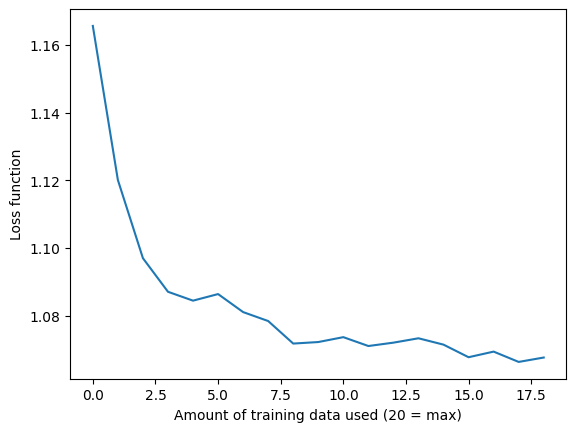

In [7]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [9]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

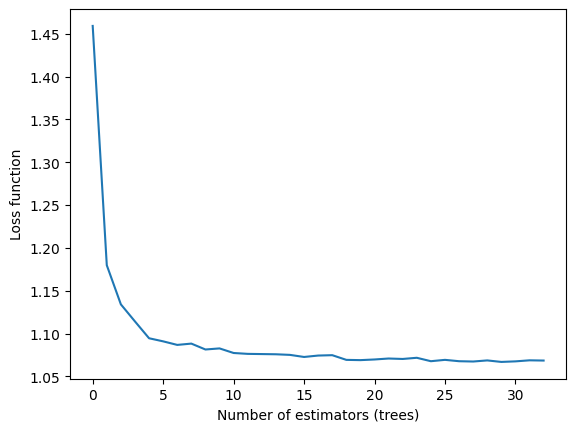

In [ ]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

## Answer
I would keep "Amount of training data" Plot 1 and cut "Number of estimators". Amount of training data is more critical as it reflects the models ability to learn more info. It shows the diminishing returns on adding data and can help guide whether to invest in obtaining more data. 

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

# Kidney Dataset

In [6]:
features_kidney = ['Age', 'BMI', 'SystolicBP', 'DiastolicBP', 'SerumCreatinine', 'BUNLevels', 'ProteinInUrine']
target_kidney = 'GFR'

df_kidney_model = df_kidney[features_kidney + [target_kidney]].dropna()

X = df_kidney_model[features_kidney]
y = df_kidney_model[target_kidney]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train, y_train)

y_pred = rf_reg.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE (Random Forest): {rmse:.2f}")

RMSE (Random Forest): 29.60


In [7]:
from sklearn.model_selection import cross_val_score

rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

cv_scores = cross_val_score(rf_reg, X, y, cv=5, scoring=rmse_scorer)
print("Cross-validated RMSEs (negative):", cv_scores)
print("Average CV RMSE:", -np.mean(cv_scores))

Cross-validated RMSEs (negative): [-30.33857553 -30.12333331 -29.27012061 -31.68435428 -30.66372634]
Average CV RMSE: 30.41602201554822


In [8]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring=rmse_scorer,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best CV RMSE (negative):", random_search.best_score_)

best_rf = random_search.best_estimator_

y_pred_best = best_rf.predict(X_test)
rmse_best = root_mean_squared_error(y_test, y_pred_best)
print(f"Tuned RF Test RMSE: {rmse_best:.2f}")

Best Params: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 5}
Best CV RMSE (negative): -30.435103677981726
Tuned RF Test RMSE: 28.99


## Kidney Conclusions: GFR Prediction
Model predicts GFR based on creatinine, protein in urine, BUN levels, blood pressure. This shows which features are useful for predicting kidney function. Cross validation shows the model is consistent. Hyperparameter avoids overfitting. RMSE = about 29 meaning predicting GFR is hard from these features alone.


# Diabetes Dataset

In [37]:
features_diabetes = ['Age', 'BMI', 'HighBP', 'HighChol', 'PhysActivity', 'Smoker', 'HvyAlcoholConsump', 'Sex']
target_diabetes = 'Diabetes_binary'

df_diabetes_model = df_diabetes[features_diabetes + [target_diabetes]].dropna()

X = df_diabetes_model[features_diabetes]
y = df_diabetes_model[target_diabetes]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Random Forest Classifier Accuracy: {accuracy:.2f}")

Random Forest Classifier Accuracy: 0.70


In [38]:
cv_scores = cross_val_score(rf_clf, X, y, cv=5, scoring='accuracy')
print("Cross-validated accuracy scores:", cv_scores)
print("Average CV accuracy:", cv_scores.mean())

Cross-validated accuracy scores: [0.68208501 0.69849353 0.70031122 0.6998161  0.70073561]
Average CV accuracy: 0.6962882928484705


In [39]:

param_dist = {
    'n_estimators': [50, 100, 200],    
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]   
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,  
    cv=5,
    scoring='accuracy',
    n_jobs=-1,          
    random_state=42
)

random_search.fit(X, y)

print("Best Params:", random_search.best_params_)
print("Best CV accuracy:", random_search.best_score_)

Best Params: {'n_estimators': 50, 'min_samples_split': 10, 'max_depth': 10}
Best CV accuracy: 0.7232502647285942


## Diabetes Conclusions
This random forest can predict diabetes with about 72% accuracy from available features like BMI activity level cholesterol etc. 

# Hypertension Dataset

In [26]:
df_hypertension = pd.read_csv('hypertension_dataset.csv')
print(df_hypertension['Hypertension'].head(10).tolist())

['High', 'High', 'Low', 'High', 'High', 'High', 'Low', 'High', 'Low', 'High']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import randint


df_hypertension['Hypertension'] = df_hypertension['Hypertension'].map({'Low': 0, 'High': 1})

features_htn = ['Age', 'BMI', 'Cholesterol', 'Smoking_Status', 'Alcohol_Intake',
                'Physical_Activity_Level', 'Stress_Level']
target_htn = 'Hypertension'


df_htn_subset = df_hypertension[features_htn + [target_htn]].dropna(subset=[target_htn])


numeric_cols = df_htn_subset[features_htn].select_dtypes(include=np.number).columns
df_htn_subset[numeric_cols] = df_htn_subset[numeric_cols].fillna(df_htn_subset[numeric_cols].median())


df_htn_encoded = pd.get_dummies(df_htn_subset, drop_first=True)

X = df_htn_encoded.drop(columns=[target_htn])
y = df_htn_encoded[target_htn]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Random Forest Classifier Accuracy (Hypertension): {accuracy:.2f}")


Random Forest Classifier Accuracy (Hypertension): 0.71


In [28]:
cv_scores = cross_val_score(rf_clf, X, y, cv=5, scoring='accuracy')
print("Cross-validated accuracy scores:", cv_scores)
print("Average CV accuracy:", cv_scores.mean())

Cross-validated accuracy scores: [0.71200389 0.71040375 0.71102412 0.71276717 0.71279575]
Average CV accuracy: 0.7117989346917651


In [32]:
param_dist_htn = {
    'n_estimators': [50, 100, 200],        
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]      
}

random_search_htn = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist_htn,
    n_iter=5,              
    cv=3,
    scoring='accuracy',
    n_jobs=-1,      
    random_state=42
)

random_search_htn.fit(X_train, y_train)

print("Best Params (Hypertension):", random_search_htn.best_params_)
print("Best CV accuracy (Hypertension):", random_search_htn.best_score_)

Best Params (Hypertension): {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 5}
Best CV accuracy (Hypertension): 0.7191699110332369


## Hypertension Conclusions: 
This model has 71% accuracy in classifying hypertension. Systolic BP, stress, age, BMI are all important factors.  

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

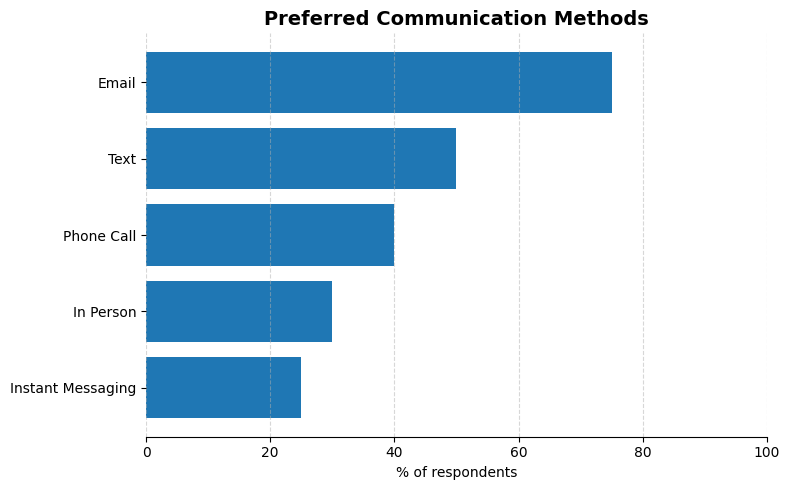

In [17]:
methods = ['Email', 'Text', 'Phone Call', 'In Person', 'Instant Messaging']
percent = [75, 50, 40, 30, 25]

methods_rev = methods[::-1]
percent_rev = percent[::-1]

plt.figure(figsize=(8, 5))
plt.barh(methods_rev, percent_rev, color='#1f77b4')

plt.title('Preferred Communication Methods', fontsize=14, weight='bold')
plt.xlabel('% of respondents')
plt.xticks(ticks=range(0, 101, 20))
plt.xlim(0, 100)

for spine in ['top', 'right', 'left']:
    plt.gca().spines[spine].set_visible(False)
plt.gca().xaxis.grid(True, linestyle='--', alpha=0.5)
plt.gca().tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()